In [44]:
import os
from pathlib import Path
import gzip 
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import torch

Data from synthtic chest left

In [45]:
from pathlib import Path

root = Path("/Users/user/Desktop/Thesis/master-thesis/SANPO Dataset Test/sanpo-synthetic/fde08012cbbe1e9d4013ba36ed99143b867ff3b14e4e0e87bfd51b238983cc10/fde08012cbbe1e9d4013ba36ed99143b867ff3b14e4e0e87bfd51b238983cc10/camera_chest/left")

rgb_dir = root / "video_frames"
seg_dir = root / "segmentation_masks"
depth_dir = root / "depth_maps"

print("RGB dir exists:", rgb_dir.exists())
print("Seg dir exists:", seg_dir.exists())
print("Depth dir exists:", depth_dir.exists())

RGB dir exists: True
Seg dir exists: True
Depth dir exists: True


In [46]:
rgb_files = sorted(rgb_dir.iterdir())
seg_files = sorted(seg_dir.iterdir())
depth_files = sorted(depth_dir.iterdir())

print("n rgb:", len(rgb_files))
print("n seg:", len(seg_files))
print("n depth:", len(depth_files))

print("first rgb files:", [f.name for f in rgb_files[:5]])
print("first seg files:", [f.name for f in seg_files[:5]])
print("first depth files:", [f.name for f in depth_files[:5]])

n rgb: 50
n seg: 50
n depth: 51
first rgb files: ['000000.png', '000001.png', '000002.png', '000003.png', '000004.png']
first seg files: ['000000.png', '000001.png', '000002.png', '000003.png', '000004.png']
first depth files: ['.DS_Store', '000000.float16.gz', '000001.float16.gz', '000002.float16.gz', '000003.float16.gz']


In [47]:
sample_idx = 0

rgb_path = rgb_files[sample_idx]
seg_path = seg_dir / rgb_path.name
depth_name = rgb_path.stem + ".float16.gz"
depth_path = depth_dir / depth_name

print(rgb_path.name)
print(seg_path.name)
print(depth_path.name)

000000.png
000000.png
000000.float16.gz


In [48]:
image = Image.open(rgb_path).convert("RGB")
seg = Image.open(seg_path)

# load compressed float16 depth
with gzip.open(depth_path, "rb") as f:
    depth = np.frombuffer(f.read(), dtype=np.float16)

# reshape depth to image height x width
w, h = image.size
depth_wo_header = depth[2:]
depth_wo_header = depth_wo_header.reshape(h, w)

print("image size:", image.size, "mode:", image.mode)
print("seg size:", seg.size, "mode:", seg.mode)
print("depth shape:", depth_wo_header.shape, "dtype:", depth_wo_header.dtype)
print("depth min/max:", np.min(depth_wo_header), np.max(depth_wo_header))

image size: (2208, 1242) mode: RGB
seg size: (2208, 1242) mode: RGB
depth shape: (1242, 2208) dtype: float16
depth min/max: 0.536 46100.0


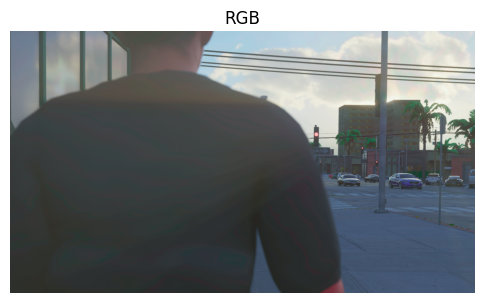

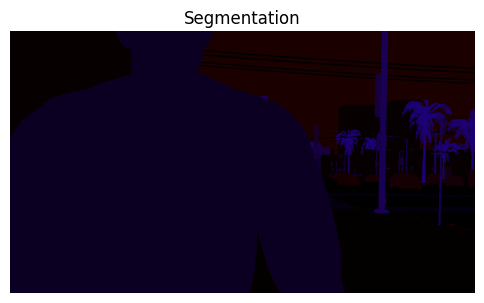

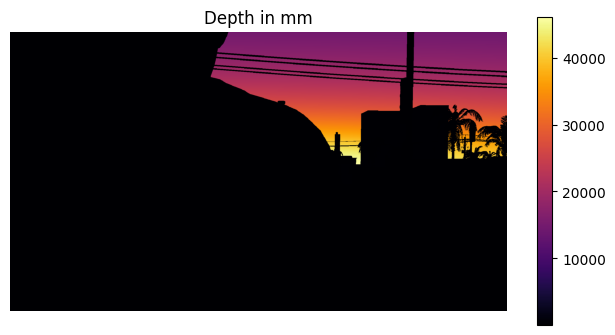

In [49]:
plt.figure(figsize=(6, 4))
plt.imshow(image)
plt.title("RGB")
plt.axis("off")

plt.figure(figsize=(6, 4))
plt.imshow(seg)
plt.title("Segmentation")
plt.axis("off")

plt.figure(figsize=(8, 4))
plt.imshow(depth_wo_header)
plt.title("Depth in mm")
plt.axis("off")
plt.imshow(depth_wo_header, cmap="inferno")
plt.colorbar()

plt.show()

Data from real chest but missing seg 

In [50]:

root2 = Path("/Users/user/Desktop/Thesis/master-thesis/SANPO Dataset Test/sanpo-real/xzZE8IX_uFMn4TDczrDP_jFNKQTYbvob/xzZE8IX_uFMn4TDczrDP_jFNKQTYbvob/camera_chest/left") 

rgb_dir2 = root2 / "video_frames"
depth_dir2 = root2 / "depth_maps"

print("RGB dir exists:", rgb_dir2.exists())
print("Depth dir exists:", depth_dir2.exists())

RGB dir exists: True
Depth dir exists: True


In [51]:
rgb_files2 = sorted(rgb_dir2.iterdir())
depth_files2 = sorted(depth_dir2.iterdir())

print("n rgb:", len(rgb_files2))
print("n depth:", len(depth_files2))

print("first rgb files:", [f.name for f in rgb_files2[:5]])
print("first depth files:", [f.name for f in depth_files2[:5]])

n rgb: 469
n depth: 469
first rgb files: ['000000.png', '000001.png', '000002.png', '000003.png', '000004.png']
first depth files: ['000000.float16.gz', '000001.float16.gz', '000002.float16.gz', '000003.float16.gz', '000004.float16.gz']


In [52]:
sample_idx = 0

rgb_path2 = rgb_files2[sample_idx]
depth_name2 = rgb_path2.stem + ".float16.gz"
depth_path2 = depth_dir2 / depth_name2

print(rgb_path2.name)
print(depth_path2.name)

000000.png
000000.float16.gz


In [53]:
image2 = Image.open(rgb_path2).convert("RGB")

# load compressed float16 depth
with gzip.open(depth_path2, "rb") as f:
    depth2 = np.frombuffer(f.read(), dtype=np.float16)

# reshape depth to image height x width
w, h = [1280, 720]
depth_wo_header2 = depth2[2:]
depth_wo_header2 = depth_wo_header2.reshape(h, w)

print("image size:", image2.size, "mode:", image2.mode)
print("depth shape:", depth_wo_header2.shape, "dtype:", depth_wo_header2.dtype)
print("depth min/max:", np.min(depth_wo_header2), np.max(depth_wo_header2))

image size: (2208, 1242) mode: RGB
depth shape: (720, 1280) dtype: float16
depth min/max: 0.0 80.0


In [54]:
print("depth:", depth2[0])
print("depth1:", depth2[1])

depth: 720.0
depth1: 1280.0


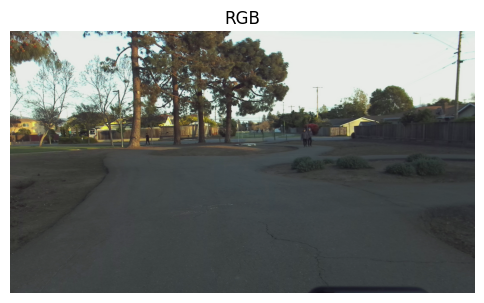

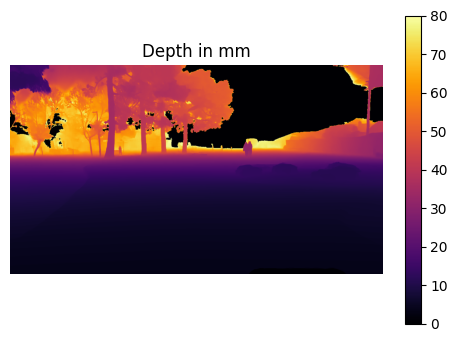

In [55]:
plt.figure(figsize=(6, 4))
plt.imshow(image2)
plt.title("RGB")
plt.axis("off")

plt.figure(figsize=(6, 4))
plt.imshow(depth_wo_header2)
plt.title("Depth in mm")
plt.axis("off")
plt.imshow(depth_wo_header2, cmap="inferno")
plt.colorbar()

plt.show()